Each Heading level is represented by different colours so our eyes won't hurt too much reading this :)  
Heading 1 - Blue  
Heading 2 - Red  
Heading 3 - Green  
Heading 4 - Orange

# <span style="color:blue"> Variable Overview</span>

Customer’s ID: Unqiue identifier (int) -> drop   
Birth Date: birth date (string) -> get age  
Gender: customer's gender (string)  
Item Purchased: purchased item (string)  
Category: purchased category (string)  
Purchase Amount (USD): amount spent for item (int)  
Location: customer’s location (string)  
Size: item size (string)  
Color: item colour (string)   
Season: season of purchase (string)  
Review Rating: rating left by customer (float)  
Subscription Status: customer’s subscription status (string)  
Payment Method: payment method (string)  
Shipping Type: shipment type (string)  
Discount Applied: use discount or no (yes/no) (string)  
Promo Code Used: use promo or no (yes/no) (string)  
Previous Purchases: months since last purchase (int)  
Preferred Payment Method: preferred payment method (string)  
Frequency of Purchases: purchase frequency (string)  

# <span style="color:Blue"> Libraries</span>

In [6]:
import os
os.environ['OMP_NUM_THREADS'] = '16'

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from sklearn.decomposition import PCA

# <span style="color:blue"> Basics</span>

## <span style="color:red"> Data Preparation and First Glance</span>

In [10]:
df = pd.read_csv("2A.tsv", sep = '\t')

In [11]:
df.head(3)

,Customer ID,Birth Date,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,1969/03/05,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,2005/07/01,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,1974/12/01,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Birth Date                3900 non-null   object 
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [13]:
df.dtypes

Customer ID                   int64
Birth Date                   object
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
dtype: object

In [14]:
for col in df.columns:
    print(df[col].value_counts())
    print()

Customer ID
1       1
2621    1
2593    1
2594    1
2595    1
       ..
1305    1
1306    1
1307    1
1308    1
3900    1
Name: count, Length: 3900, dtype: int64

Birth Date
1970/12/28    3
1965/08/28    3
1966/12/27    3
1970/08/27    3
1969/05/14    3
             ..
1985/06/23    1
1996/09/02    1
1984/01/21    1
1972/03/05    1
1980/03/30    1
Name: count, Length: 3534, dtype: int64

Gender
Male      2642
Female    1231
f           17
M           10
Name: count, dtype: int64

Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

Category
Clothing      

## <span style="color:red"> Nulls and Duplicates</span>

In [16]:
df.isna().sum()

Customer ID                 0
Birth Date                  0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [17]:
df.duplicated().sum()

0

No nulls and duplicates, no need to drop and impute

# <span style="color:blue"> Feature Engineering</span>

## <span style="color:red"> Drops and Alterations </span>

### <span style="color:green"> Drop ID </span>

In [22]:
# Why drop ID? It's only a unique identifier for each row, it won't affect the outcome
df = df.drop(columns = ['Customer ID'])

In [23]:
df.head(1)

,Birth Date,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1969/03/05,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly


### <span style="color:green"> Birth Date </span>

Why use birth date now and not in 1? in 1, a medical diagnosis needs to be very specific, it wouldn't reflect the patient's age and lead to dangerous risks.

On the other hand, when using K-Means, we're not predicting any outcome, we're trying to find an age group, hence why use it here and not in the last number

In [26]:
df['Birth Date'] = pd.to_datetime(df['Birth Date'], format='%Y/%m/%d')
tdy = datetime(2025,1,14)
df['Age'] = tdy.year - df['Birth Date'].dt.year

In [27]:
df = df.drop(columns = ['Birth Date'])

In [28]:
df.head(1)

,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Age
0,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,56


### <span style="color:green"> Gender Typo fix </span>

In [30]:
df['Gender'].value_counts()

Gender
Male      2642
Female    1231
f           17
M           10
Name: count, dtype: int64

In [31]:
df['Gender'] = df['Gender'].replace({
    'f': 'Female',
    'M': 'Male'
})

In [32]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

### <span style="color:green"> Renames </span>

For the sake of clarity and efficiency

In [35]:
df.rename(columns = {'Previous Purchases': 'Last Purchase',
                     'Item Purchased': 'Item',
                     'Purchase Amount (USD)': 'Price',
                     'Review Rating': 'Rating',
                     'Subscription Status': 'Subscribed',
                     'Discount Applied': 'Discount',
                     'Promo Code Used': 'Promo',
                     'Preferred Payment Method': 'Preferred Payment',
                     'Payment Method': 'Payment',
                     'Frequency of Purchases': 'Frequency',
                     'Color': 'Colour',
                     'Shipping Type': 'Shipping'}, inplace = True)

### <span style="color:green"> Frequency Redundancy Fix </span>

Both, Bi-Weekly and Fortnightly means per two weeks, quarterly and every 3 months are also the same thing, sooo merge!

In [38]:
df['Frequency'] = df['Frequency'].replace({
    'Fortnightly': 'Bi-Weekly',
    'Every 3 Months': 'Quarterly'
})

### <span style="color:green"> Discount/Promo Redundancy Fix </span>

They have the exact same counts for yes and no, they are redundant, let's drop promo

In [41]:
df = df.drop(columns = ['Promo'])

## <span style="color:red"> Recheck Value Counts </span>

In [43]:
for col in df.columns:
    print(df[col].value_counts())
    print()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

Item
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Price
94     62
32     62
36     62
51     61
90     60
       ..
100    36
87     35
49     35
69     34
61     33
Name: count, Length: 81, dtype: int64

Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
Nebraska          87
New York          87
Nevada

No more typos in categorical variables. If there were mis-inputs in numerical variables, OH WELL, can't check it, we can only consider them outliers later on

## <span style="color:red"> Categorising Variables </span>

In [46]:
num_col = ['Age','Price', 'Rating', 'Last Purchase']
cat_col = ['Gender', 'Item', 'Category', 'Location', 'Size', 'Colour',
           'Season', 'Subscribed', 'Payment', 'Shipping', 'Discount',
           'Preferred Payment', 'Frequency']
ohe_col = ['Item', 'Category', 'Location', 'Colour', 'Season', 'Payment', 'Shipping', 'Preferred Payment']
lab_col = ['Gender', 'Subscribed', 'Discount']
ord_col = ['Size', 'Frequency']

In [47]:
df.head(1)

,Gender,Item,Category,Price,Location,Size,Colour,Season,Rating,Subscribed,Payment,Shipping,Discount,Last Purchase,Preferred Payment,Frequency,Age
0,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,14,Venmo,Bi-Weekly,56


In [48]:
df[num_col].head(1)

,Age,Price,Rating,Last Purchase
0,56,53,3.1,14


In [49]:
df[cat_col].head(1)

,Gender,Item,Category,Location,Size,Colour,Season,Subscribed,Payment,Shipping,Discount,Preferred Payment,Frequency
0,Male,Blouse,Clothing,Kentucky,L,Gray,Winter,Yes,Credit Card,Express,Yes,Venmo,Bi-Weekly


## <span style="color:red"> Preparing Ordinals</span>

In [51]:
yn = ['No', 'Yes'] # Makes sure No is always 0 and Yes is always 1
mf = ['Male', 'Female'] # Makes sure that Male is 0 and Female is 1
sz = ['S', 'M', 'L', 'XL'] # Set ordinal order for size, small to big
fq = ['Weekly', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Annually'] # from most frequent to least

# <span style="color:blue"> EDA</span>

## <span style="color:red"> Numerical Variables</span>

In [54]:
df[num_col].describe()

,Age,Price,Rating,Last Purchase
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,45.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,19.000000,20.000000,2.500000,1.000000
25%,32.000000,39.000000,3.100000,13.000000
50%,45.000000,60.000000,3.700000,25.000000
75%,58.000000,81.000000,4.400000,38.000000
max,71.000000,100.000000,5.000000,50.000000


For now, everything still seems relatively balanced, no significant outliers

## <span style="color:red"> Categorical Variables</span>

In [57]:
for col in cat_col:
  print(df[col].value_counts(), '\n')

Gender
Male      2652
Female    1248
Name: count, dtype: int64 

Item
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64 

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64 

Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
Nebraska          87
New York          87
Nevada            87
Maryland          86
Delaware          86
Vermont           85
Louisiana         84
North Dakota      83
Missouri          81
West Virgin

We have two ordinals, a few binaries, and a LOT of One-Hot for later

## <span style="color:red"> Numerical</span>

### <span style="color:green"> Histogram & Box Plot - Outliers</span>

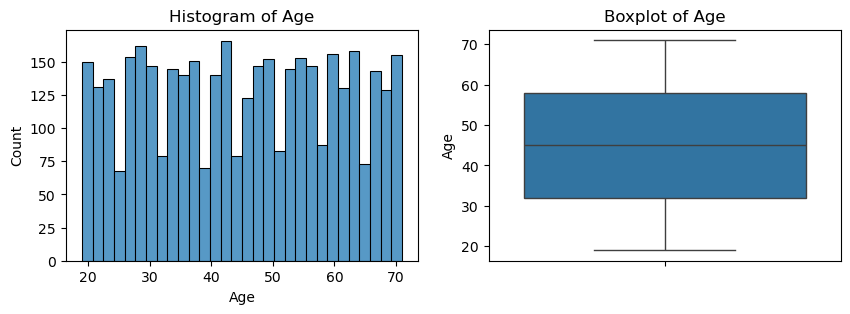

Skewness of Age: -0.0063797217209905395
Kurtosis of Age: -1.1950871489241808


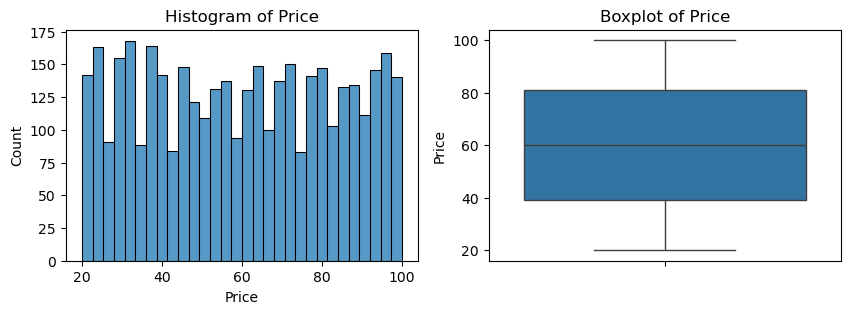

Skewness of Price: 0.012701757626433795
Kurtosis of Price: -1.236593691266159


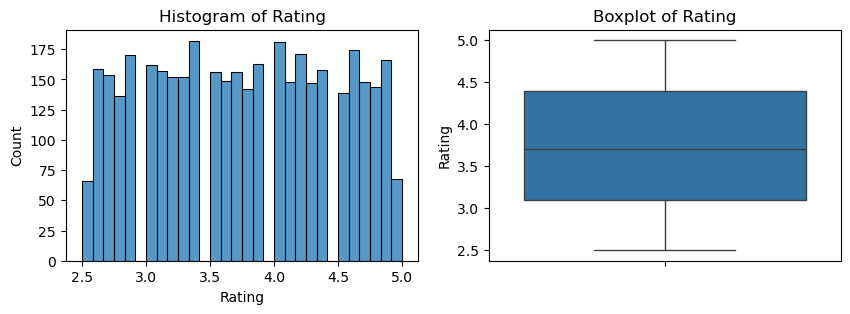

Skewness of Rating: 0.00452459644246527
Kurtosis of Rating: -1.1796283021299137


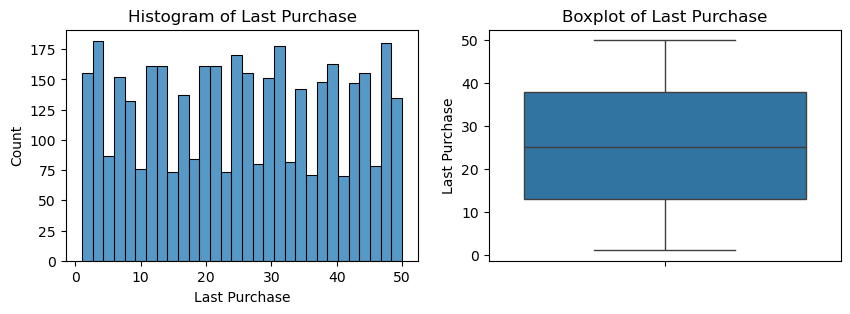

Skewness of Last Purchase: 0.0031211555127652127
Kurtosis of Last Purchase: -1.1901873846405375


In [61]:
def check_distribution_outliers(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 3))

        plt.subplot(1, 2, 1)
        sns.histplot(df[col], bins=30)
        plt.title(f'Histogram of {col}')

        plt.subplot(1, 2, 2)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col}')

        plt.show()

        print(f'Skewness of {col}:', df[col].skew())
        print(f'Kurtosis of {col}:', df[col].kurt())

check_distribution_outliers(df[num_col], num_col)

Cool! The data set has absolutely no outliers, the data in the histogram also appears to be somewhat evenly spread-out

### <span style="color:green"> Correlation Heatmap</span>

<Axes: >

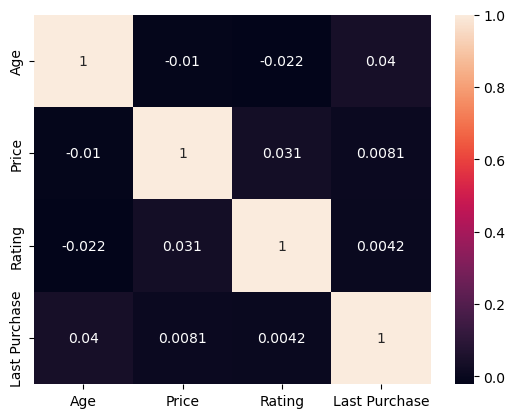

In [64]:
sns.heatmap(df[num_col].corr(), annot=True)

No variables are too highly correlated with one another, they all should be used for clustering later on

## <span style="color:red"> Categorical</span>

### <span style="color:green"> Binary - Gender, Subscription, Discount</span>

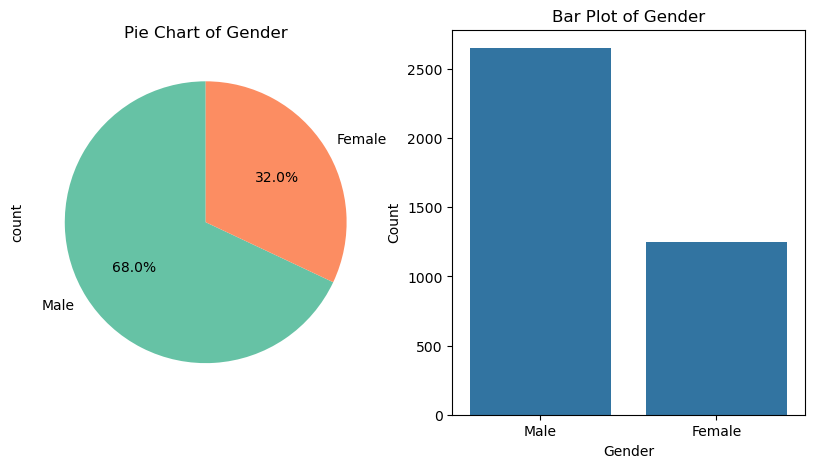

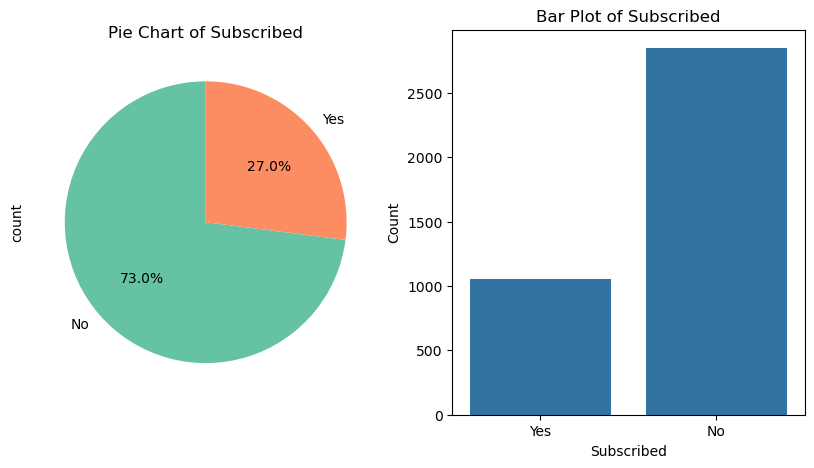

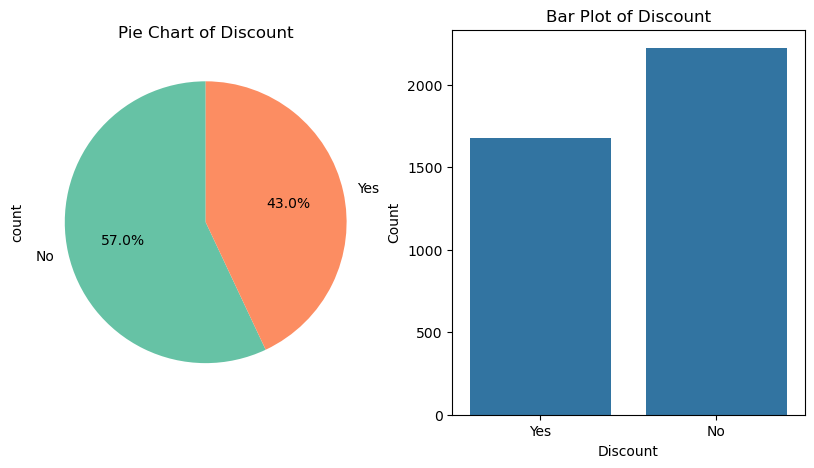

In [68]:
def binary_graph(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
        plt.title(f'Pie Chart of {col}')

        plt.subplot(1, 2, 2)
        sns.countplot(data=df, x=col)
        plt.title(f'Bar Plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

binary_graph(df[lab_col], lab_col)

1. There seems to be a significant number of males, slightly more than twice of females. This may indicate that the brand is more popular among men.
2. There aren't many subscribers as opposed to non-subscribers, this may indicate that most people only go to the store for once-in-a-while occasions and rarely regularly
3. Seeing that this store has more transactions without discounts and promos, it may indicate that the store has a decent reputation. This can mean that the prices itself are already relatively cheap, but this doesn't seem to be the case as the purchases range from 20-100 USD. The other way we can see it is that this store already has a good enough reputation(or marketing) that people find it worth-it regardless of price

*Clothing in the USA generally ranges from 10-100 USD  
https://jinfengapparel.com/what-is-the-typical-price-range-for-clothing-in-the-usa-2/

### <span style="color:green"> Ordinal - Size & Frequency</span>

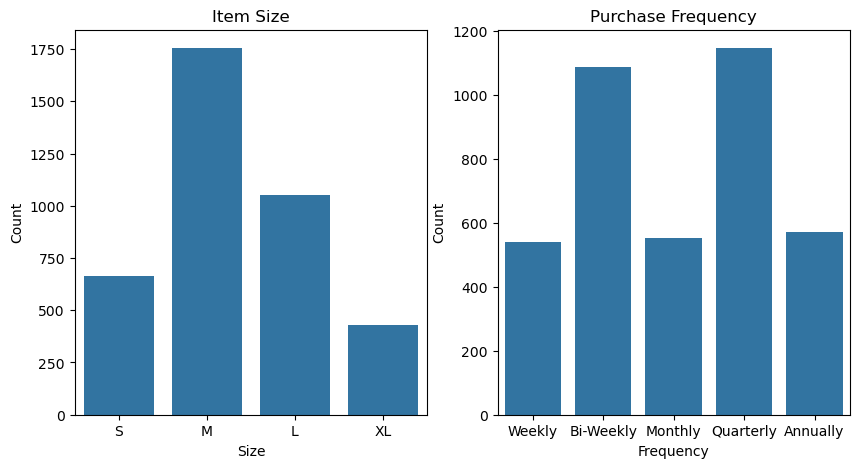

In [71]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x=df['Size'], order=sz)
plt.title('Item Size')
plt.xlabel('Size')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x=df['Frequency'], order=fq)
plt.title('Purchase Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.show()

There isn't much that we can get from here except that Size seems pretty normally distributed

Wanted to say the same for frequency, but monthly seems like an anomaly between every two weeks and every 3 months

### <span style="color:green"> One-Hot - Everything Else</span>

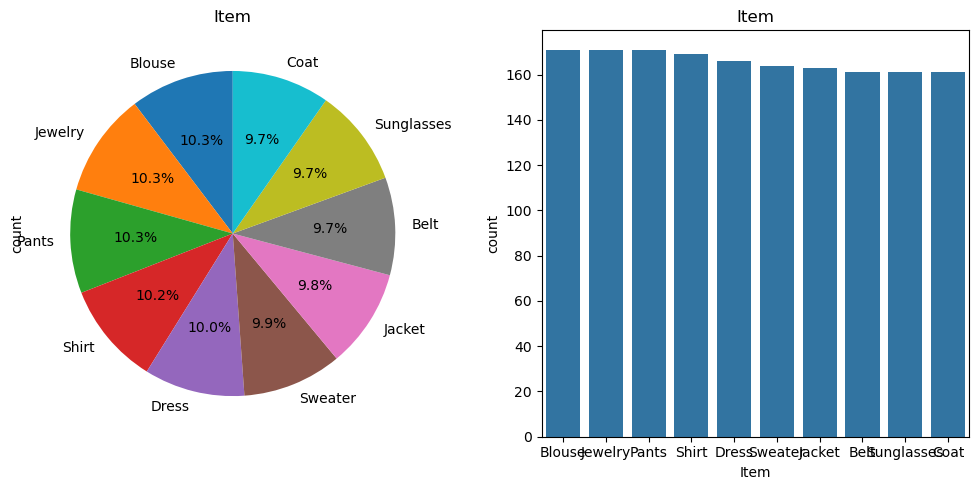

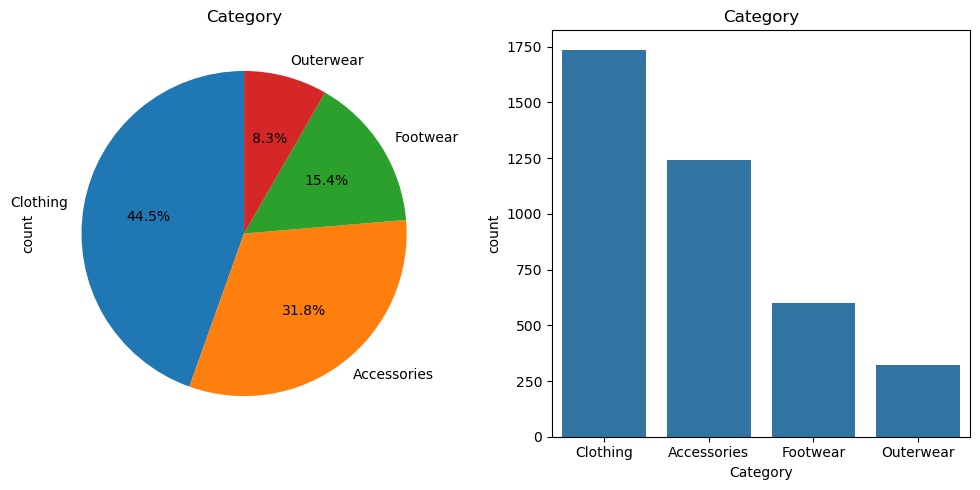

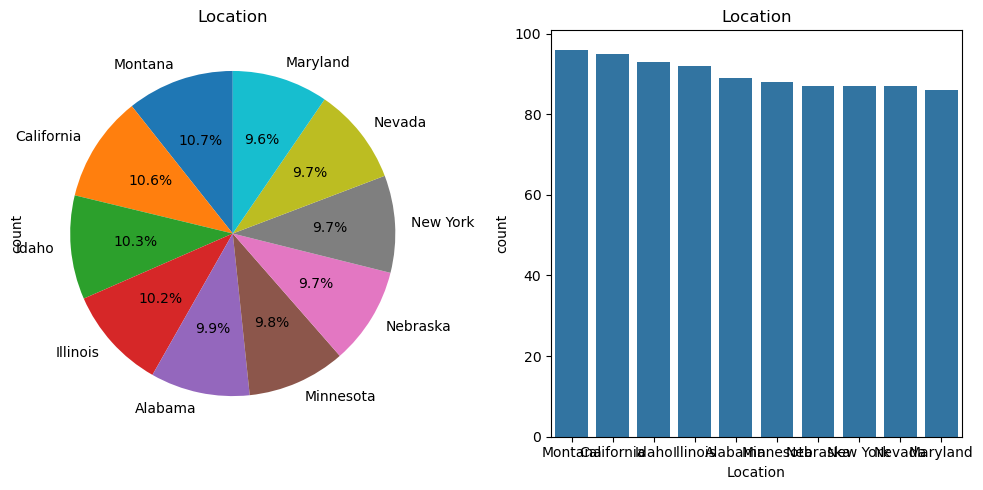

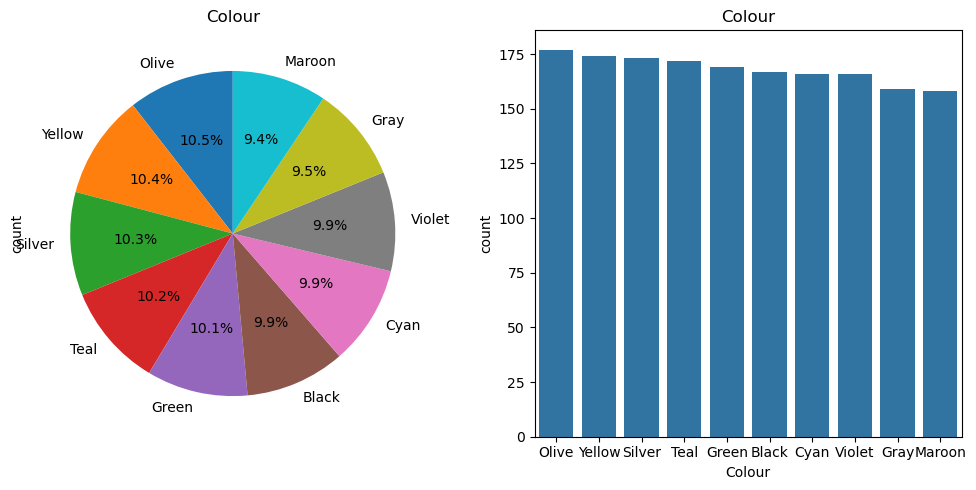

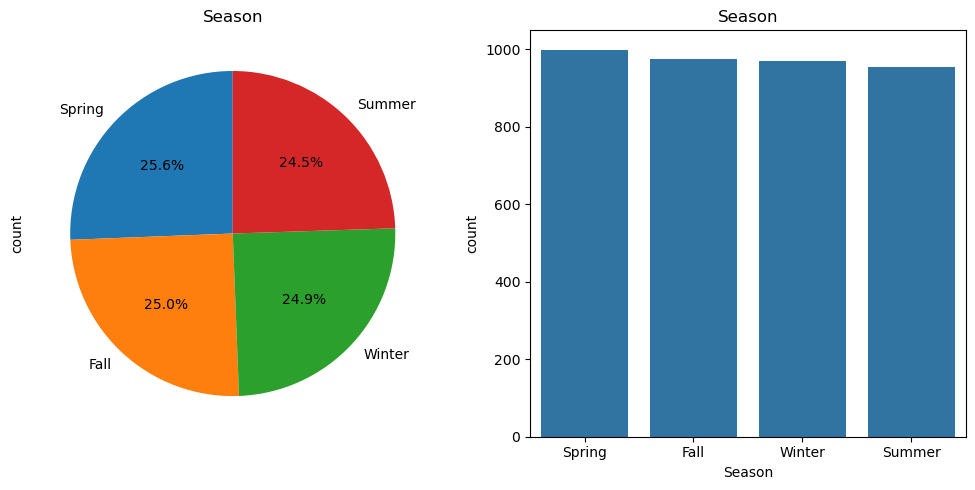

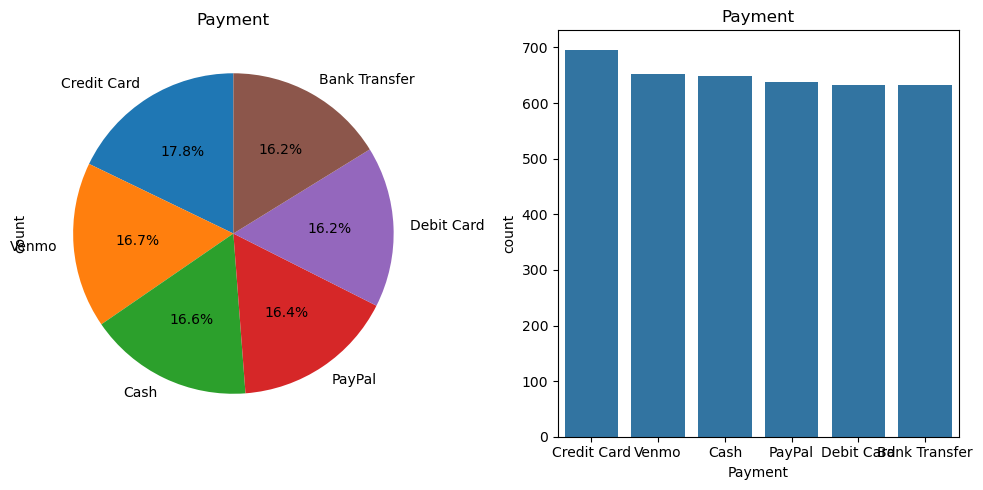

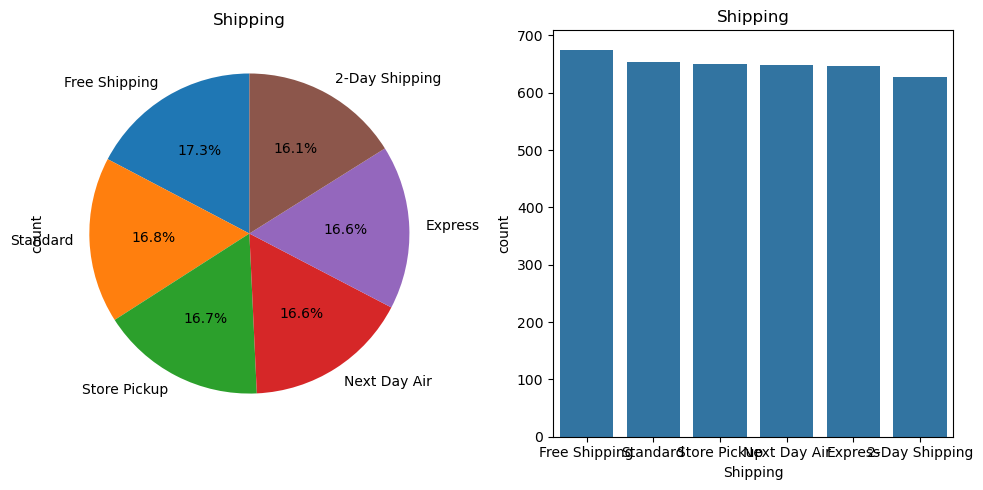

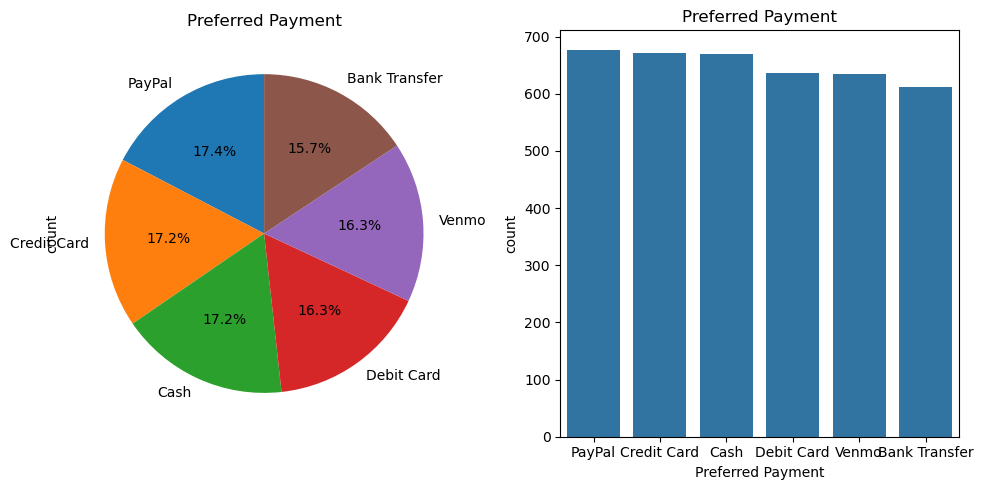

In [74]:
def ohe_graph(df, columns, n=10):
    for col in columns:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        df[col].value_counts().head(n).plot.pie(autopct='%1.1f%%', startangle=90)
        plt.title(f'{col}')

        plt.subplot(1, 2, 2)
        top_values = df[col].value_counts().head(n).index
        sns.countplot(data=df[df[col].isin(top_values)], x=col, order=top_values)
        plt.title(f'{col}')
        plt.xlabel(col)

        plt.tight_layout()
        plt.show()

ohe_graph(df[ohe_col], ohe_col)

Looking at the even distributions, and miniscule differences in their top values, it is very safe to say that most of these, if not all, don't have a clear trend. We would have to leave it up to the K-Means to sort them into categories

# <span style="color:blue"> Pre-Processing</span>

There aren't any missing values, hence we do not need to drop or impute any rows.

In [78]:
# For use later on, to make a new column, "Cluster"
alt = df.copy()

## <span style="color:red"> Encoding</span>

### <span style="color:green"> Binary/Label</span>

#### <span style="color:orange"> Subscription Status & Discount/Promo</span>

In [82]:
yn_enc = OrdinalEncoder(categories=[yn, yn])
df[['Subscribed', 'Discount']] = yn_enc.fit_transform(df[['Subscribed', 'Discount']])

#### <span style="color:orange"> Gender</span>

In [84]:
mf_enc = OrdinalEncoder(categories = [mf])
df['Gender'] = mf_enc.fit_transform(df[['Gender']])

### <span style="color:green"> Ordinal</span>

#### <span style="color:orange"> Item Size</span>

In [87]:
sz_enc = OrdinalEncoder(categories = [sz])
df['Size'] = sz_enc.fit_transform(df[['Size']])

#### <span style="color:orange"> Frequency</span>

In [89]:
fq_enc = OrdinalEncoder(categories = [fq])
df['Frequency'] = fq_enc.fit_transform(df[['Frequency']])

### <span style="color:green"> One-Hot</span>

In [91]:
ohe_enc = OneHotEncoder(sparse_output=False, drop='first')
enc_dat = ohe_enc.fit_transform(df[ohe_col])
new_col = ohe_enc.get_feature_names_out(ohe_col)
ohe_df = pd.DataFrame(enc_dat, columns=new_col)

In [92]:
df = pd.concat([df.drop(columns=ohe_col), ohe_df], axis=1)

### <span style="color:green"> Recheck</span>

In [94]:
df.head(1)

,Gender,Price,Size,Rating,Subscribed,Discount,Last Purchase,Frequency,Age,Item_Belt,...,Shipping_Express,Shipping_Free Shipping,Shipping_Next Day Air,Shipping_Standard,Shipping_Store Pickup,Preferred Payment_Cash,Preferred Payment_Credit Card,Preferred Payment_Debit Card,Preferred Payment_PayPal,Preferred Payment_Venmo
0,0.0,53,2.0,3.1,1.0,1.0,14,1.0,56,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## <span style="color:red"> Scaling</span>

We're using Min-Max scaler here as K-Means uses Euclidean distance and it would be better for eacch variable to have similar ranges so that one does not dominate over the other

In [97]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

df = pd.DataFrame(scaled, columns=df.columns)

In [98]:
df.head()

,Gender,Price,Size,Rating,Subscribed,Discount,Last Purchase,Frequency,Age,Item_Belt,...,Shipping_Express,Shipping_Free Shipping,Shipping_Next Day Air,Shipping_Standard,Shipping_Store Pickup,Preferred Payment_Cash,Preferred Payment_Credit Card,Preferred Payment_Debit Card,Preferred Payment_PayPal,Preferred Payment_Venmo
0,0.0,0.4125,0.666667,0.24,1.0,1.0,0.265306,0.25,0.711538,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.5500,0.666667,0.24,1.0,1.0,0.020408,0.25,0.019231,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.6625,0.000000,0.24,1.0,1.0,0.448980,0.00,0.615385,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.8750,0.333333,0.40,1.0,1.0,0.979592,0.00,0.057692,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.3625,0.333333,0.08,1.0,1.0,0.612245,1.00,0.519231,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## <span style="color:red"> Dimensionality Reduction</span>

In [100]:
pca = PCA()
pca.fit(df)

PCA()

Text(0, 0.5, 'Eigenvalues')

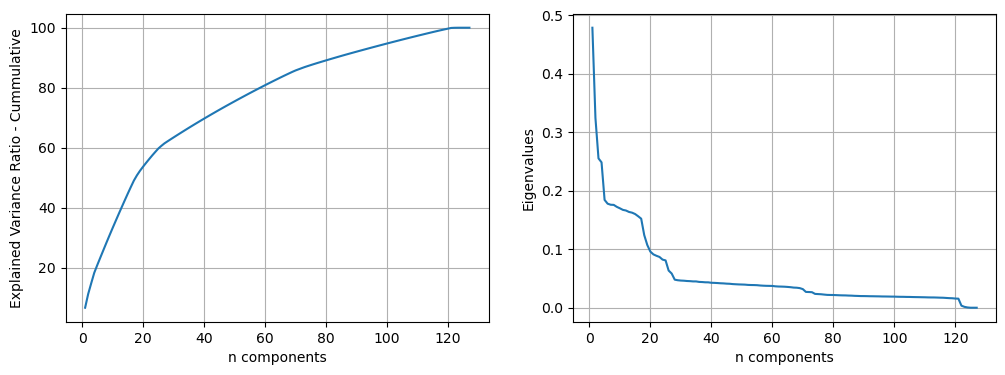

In [101]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, len(df.columns)+1), np.cumsum(pca.explained_variance_ratio_ * 100))
plt.xlabel('n components')
plt.ylabel('Explained Variance Ratio - Cummulative')

plt.subplot(1, 2, 2)
plt.grid()
plt.plot(range(1, len(df.columns)+1), pca.explained_variance_ )
plt.xlabel('n components')
plt.ylabel('Eigenvalues')

!!!Too small, cant find elbow/knee!!!

(0.0, 10.0)

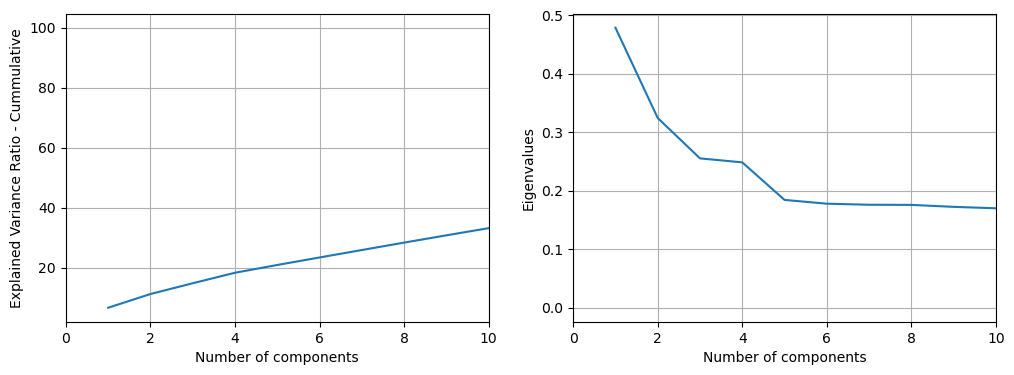

In [103]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, len(df.columns)+1), np.cumsum(pca.explained_variance_ratio_ * 100))
plt.xlabel('Number of components')
plt.ylabel('Explained Variance Ratio - Cummulative')
plt.xlim(0,10)

plt.subplot(1, 2, 2)
plt.grid()
plt.plot(range(1, len(df.columns)+1), pca.explained_variance_ )
plt.xlabel('Number of components')
plt.ylabel('Eigenvalues')
plt.xlim(0,10)

We'll use n = 2 as the elbow/knee on both graphs are found at 2

In [105]:
pca_comp = PCA(n_components=2)
pca_df = pca_comp.fit_transform(df)

In [106]:
pca_df

array([[ 0.89632437,  0.71498076],
       [ 0.89527842,  0.73560526],
       [ 0.90183029,  0.61674202],
       ...,
       [-0.77370373, -0.33822356],
       [-0.75136825, -0.92095374],
       [-0.75580513, -0.38846618]])

# <span style="color:blue"> Clustering</span>

## <span style="color:red"> Setup</span>

In [109]:
inr = []
sil = []
K = [2,4,8,12]

Why only up to 5 clusters? Because our context is customer segments, if we do too many, it will most likely end up being ineffective and over-fitted, even though high distinction between clusters

## <span style="color:red"> Silhouette Score</span>

In [112]:
for k in K:
    kmeanModel = KMeans(n_clusters=k,random_state=111)
    cls_lab = kmeanModel.fit_predict(pca_df)
    
    sil_avg = silhouette_score(pca_df, cls_lab)
    print(
        "For n_clusters =",k,
        "The average silhouette_score is :",sil_avg,
        )
    
    inr.append(kmeanModel.inertia_)
    sil.append(sil_avg)

For n_clusters = 2 The average silhouette_score is : 0.4874506889608034
For n_clusters = 4 The average silhouette_score is : 0.6698424980831738
For n_clusters = 8 The average silhouette_score is : 0.7310745921893942
For n_clusters = 12 The average silhouette_score is : 0.7869549484599581


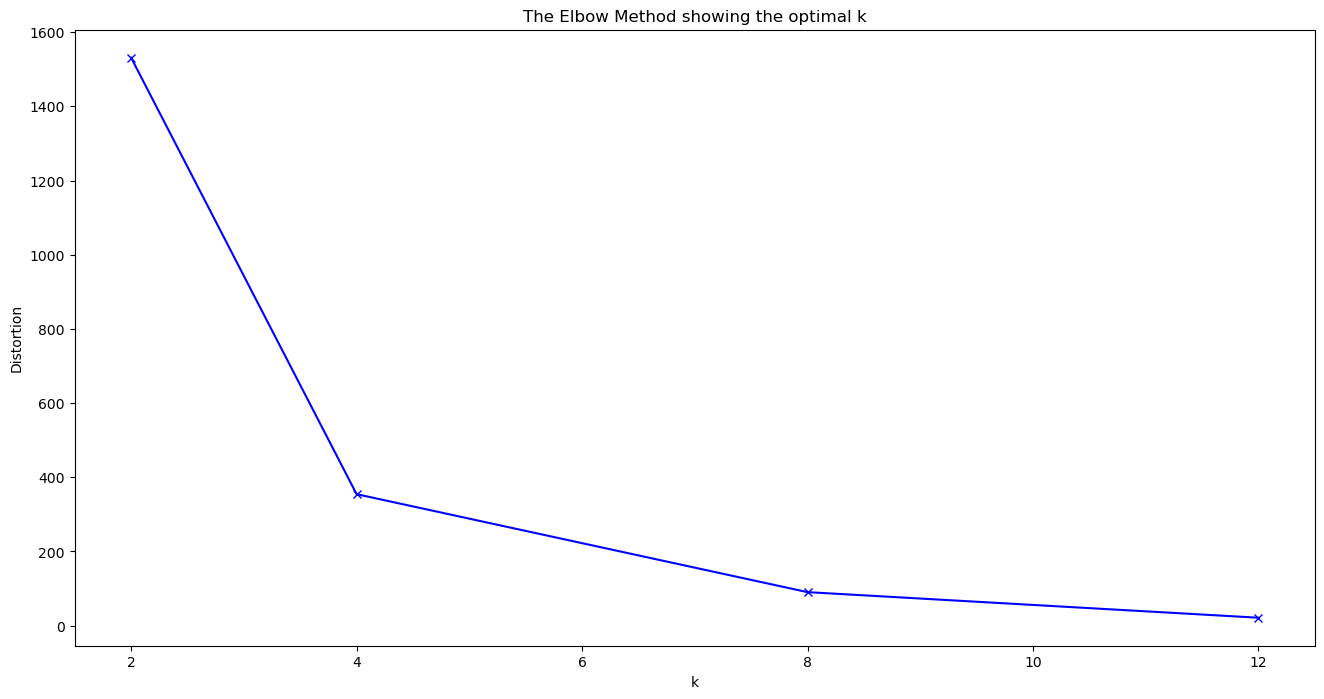

In [113]:
plt.figure(figsize=(16,8))
plt.plot(K, inr, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

## <span style="color:red"> Silhouette Sample</span>

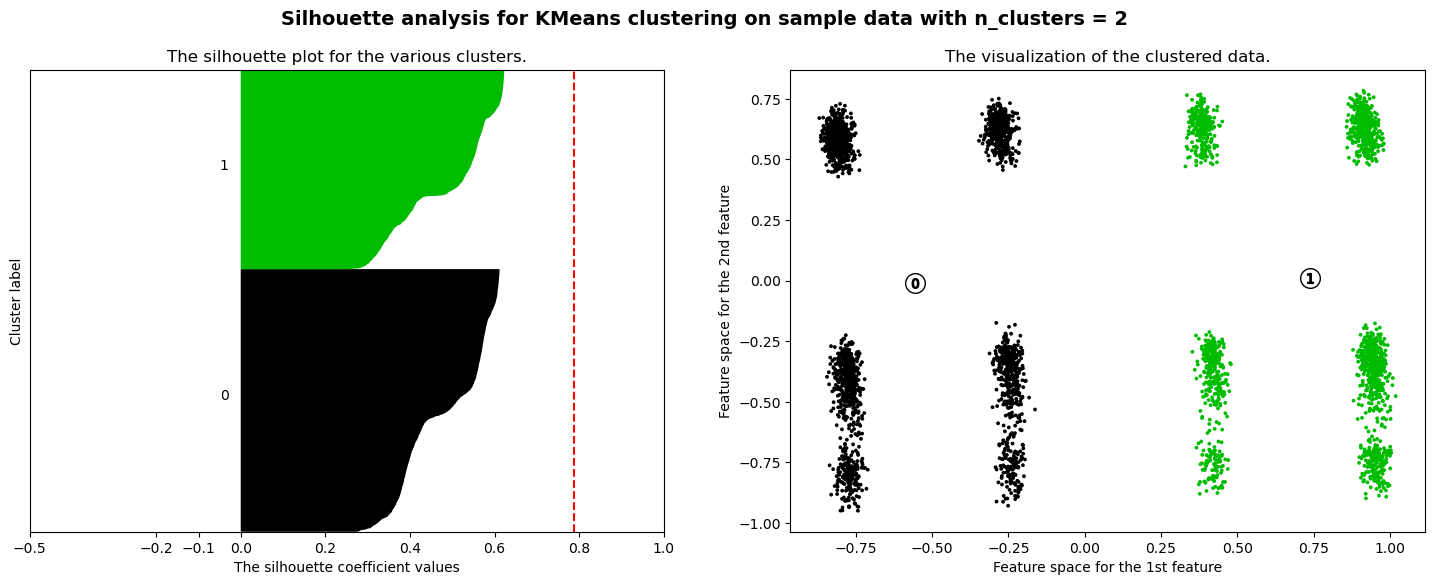

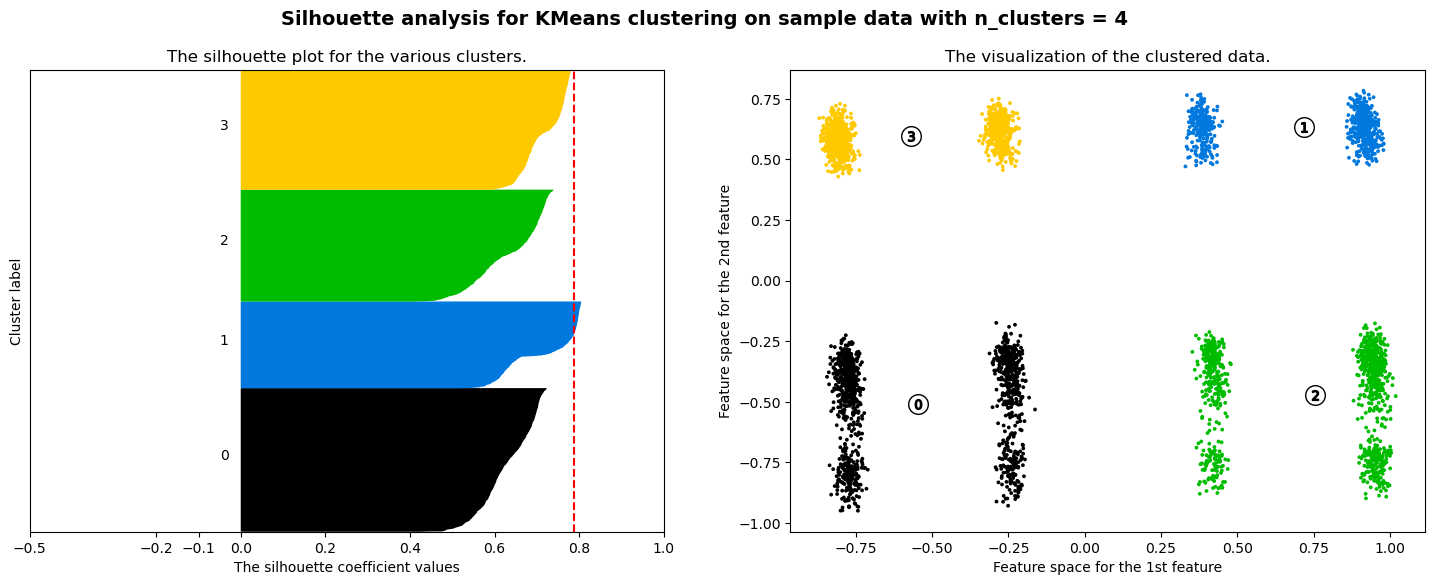

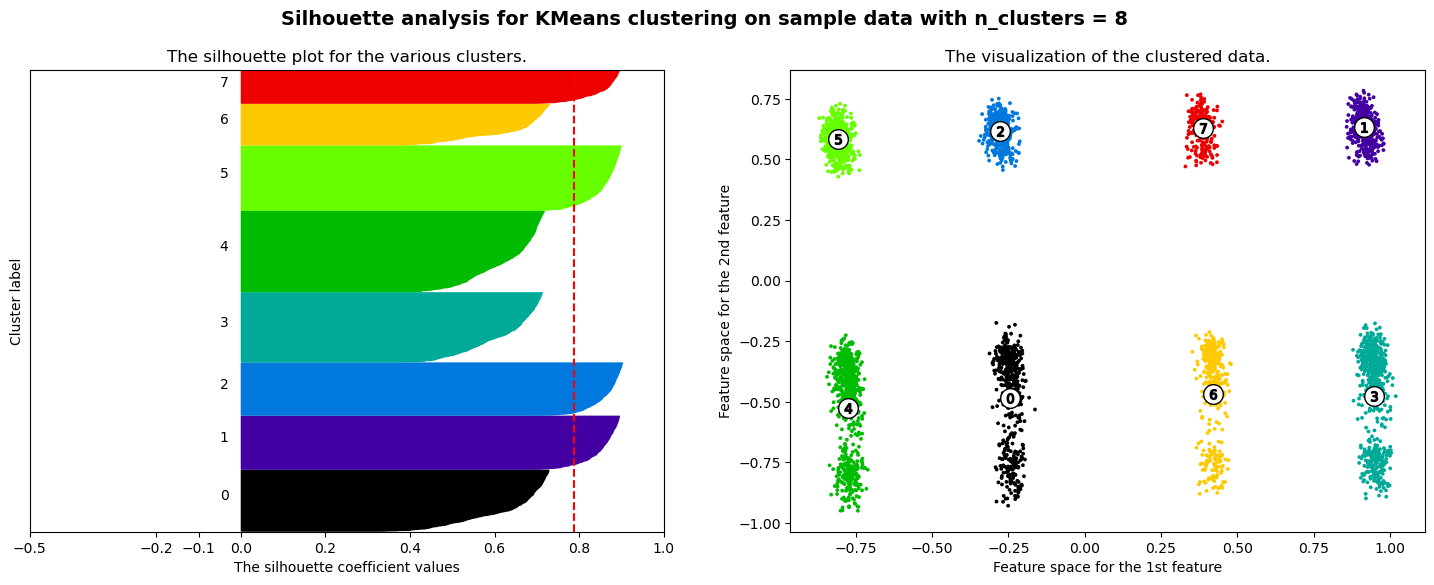

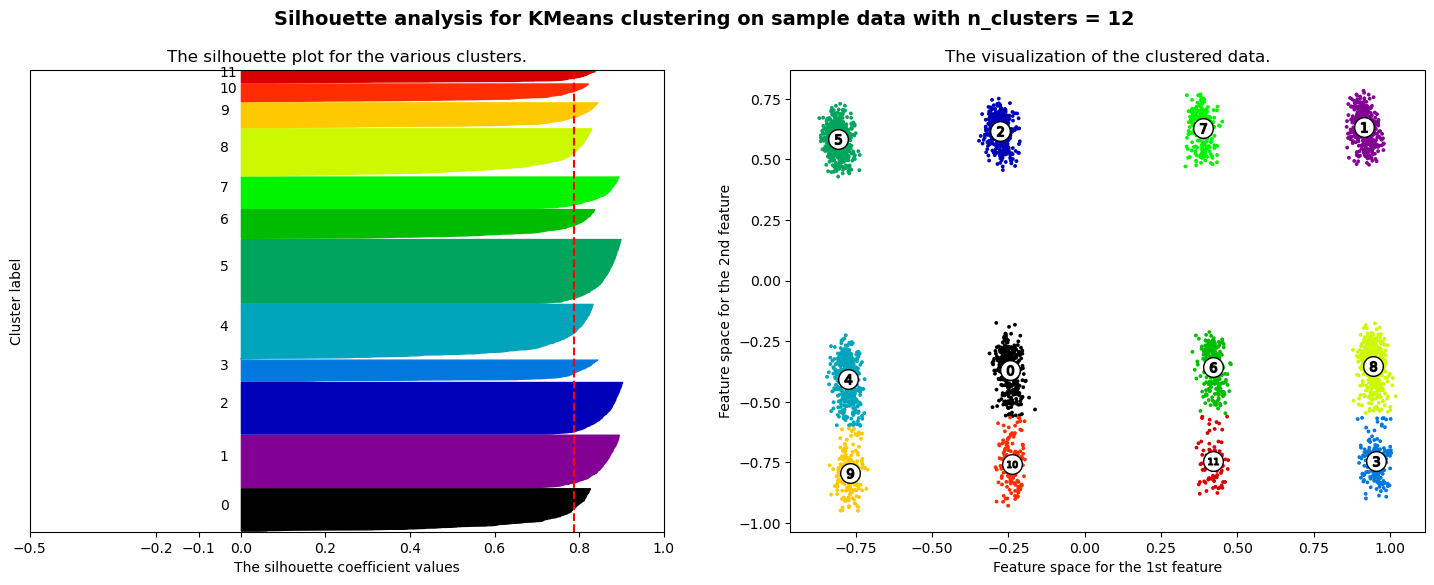

In [115]:
for n_clusters in K:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 6)

    ax1.set_xlim([-0.5, 1])
    ax1.set_ylim([0, len(pca_df) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=111)
    cluster_labels = clusterer.fit_predict(pca_df)

    sample_silhouette_values = silhouette_samples(pca_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=1,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=sil_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.5,-0.2,-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

    pca_comp = PCA(n_components=2)
    pca_df_2 = pca_comp.fit_transform(df)

    ax2.scatter(
        pca_df_2[:, 0], pca_df_2[:, 1], marker=".", s=30, lw=0, alpha=1, c=colors, edgecolor="k"
    )

    centers = clusterer.cluster_centers_
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## <span style="color:red"> Brief Conclusion</span>

In [117]:
model = KMeans(n_clusters = 4, random_state = 111)
pred = model.fit_predict(pca_df)

Out of the 4 options for n_clusters(and across various seeds), n=4 showed the best distinction and clearest visualisation despite its low silhouette score. It would be best to move further with this result to avoid overfitting the data with too many clusters.

# <span style="color:blue"> Graphs</span>

## <span style="color:red"> Preparation</span>

In [121]:
#Add the cluster column to the dataset before pre-processing
alt['Cluster'] = pred

In [122]:
alt.head(1)

,Gender,Item,Category,Price,Location,Size,Colour,Season,Rating,Subscribed,Payment,Shipping,Discount,Last Purchase,Preferred Payment,Frequency,Age,Cluster
0,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,14,Venmo,Bi-Weekly,56,1


In [123]:
seg = alt.groupby('Cluster')

## <span style="color:red"> Box Plot - Numerical</span>

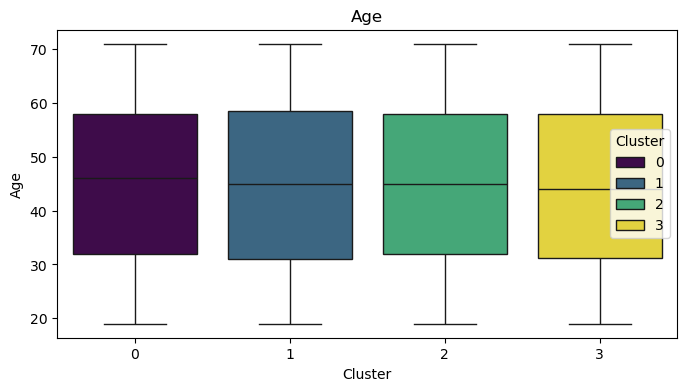

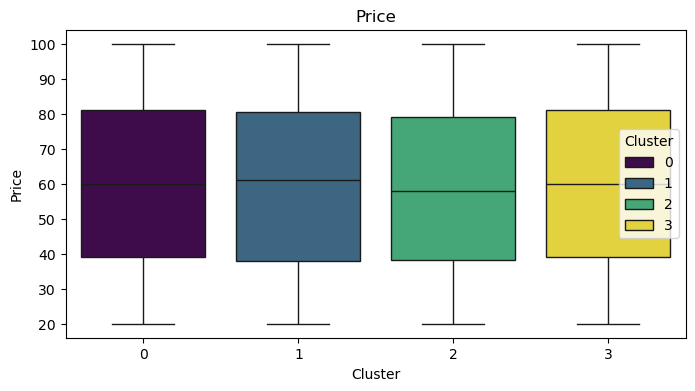

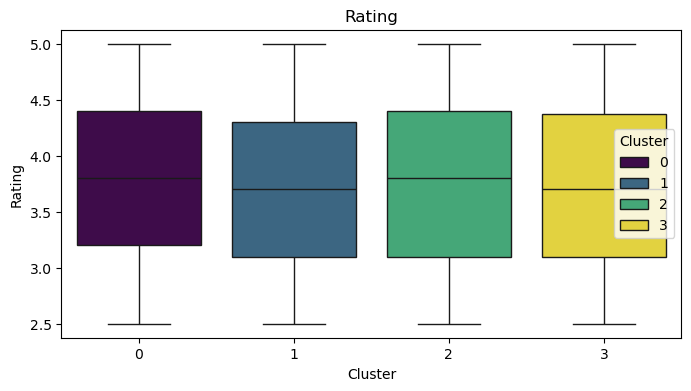

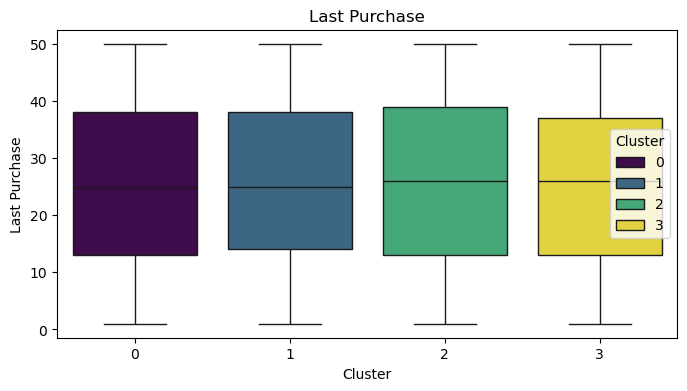

In [125]:
def numerical_distribution(columns):
    for col in columns:
        plt.figure(figsize=(8, 4))

        sns.boxplot(x = alt['Cluster'], y = alt[col], hue = alt['Cluster'], palette='viridis', dodge=False)
        plt.title(col)

        plt.show()

#Compare each stage
numerical_distribution(num_col)

## <span style="color:red"> Bar Chart - Categorical</span>

### <span style="color:green"> Binary - Gender, Subscription, Discount</span>

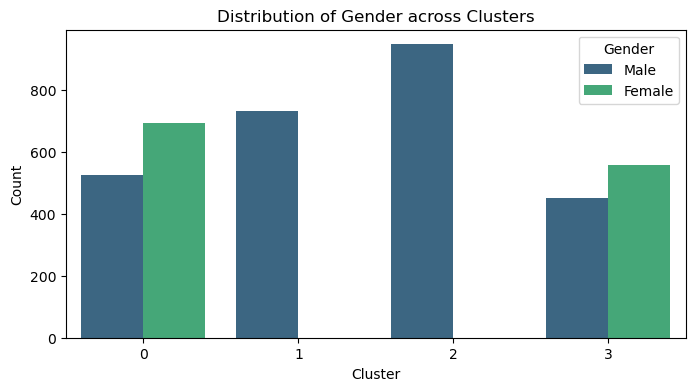

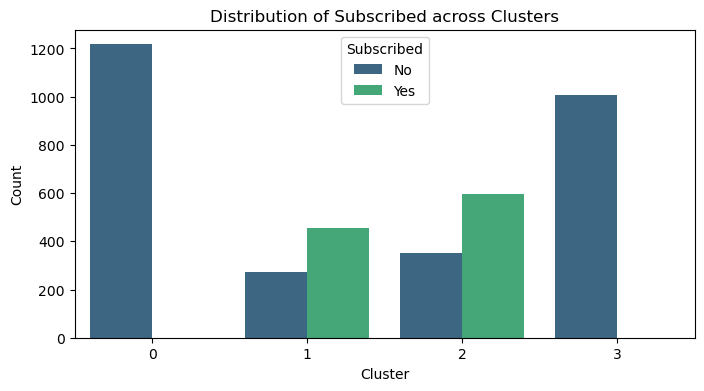

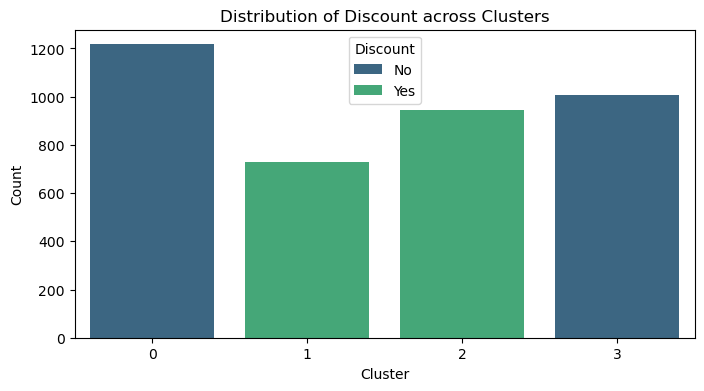

In [128]:
def binary_graph(columns):
    for col in columns:
        plt.figure(figsize=(8, 4))

        sns.countplot(data=alt, x='Cluster', hue=col, palette='viridis')
        plt.title(f'Distribution of {col} across Clusters')
        plt.xlabel('Cluster')
        plt.ylabel('Count')
        plt.legend(title=col)

        plt.show()

binary_graph(lab_col)

### <span style="color:green"> Ordinal - Size & Frequency</span>

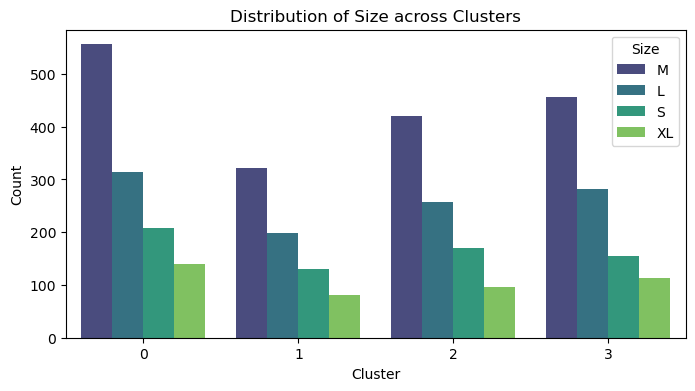

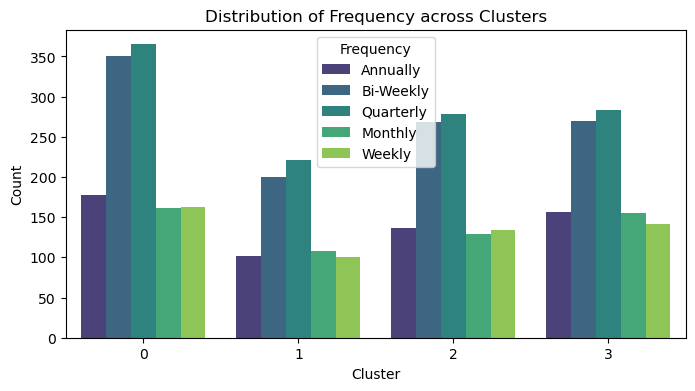

In [130]:
def ordinal_graph(columns):
    for col in columns:
        plt.figure(figsize=(8, 4))

        sns.countplot(data=alt, x='Cluster', hue=col, palette='viridis')
        plt.title(f'Distribution of {col} across Clusters')
        plt.xlabel('Cluster')
        plt.ylabel('Count')
        plt.legend(title=col)

        plt.show()

ordinal_graph(ord_col)

### <span style="color:green"> One-Hot - Everything Else</span>

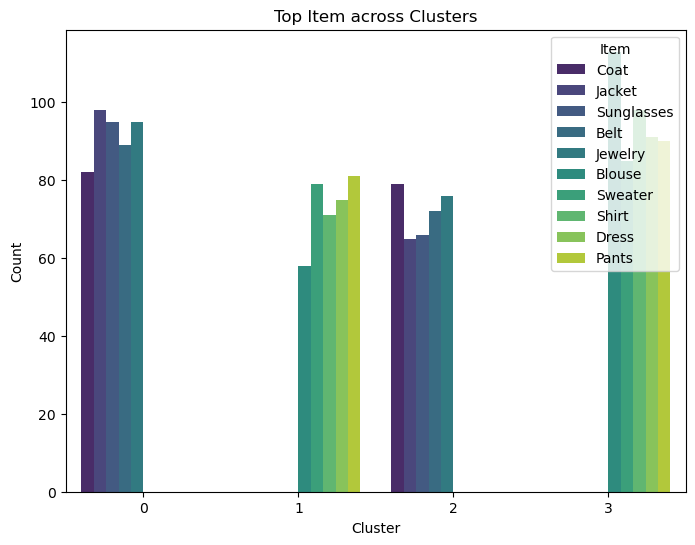

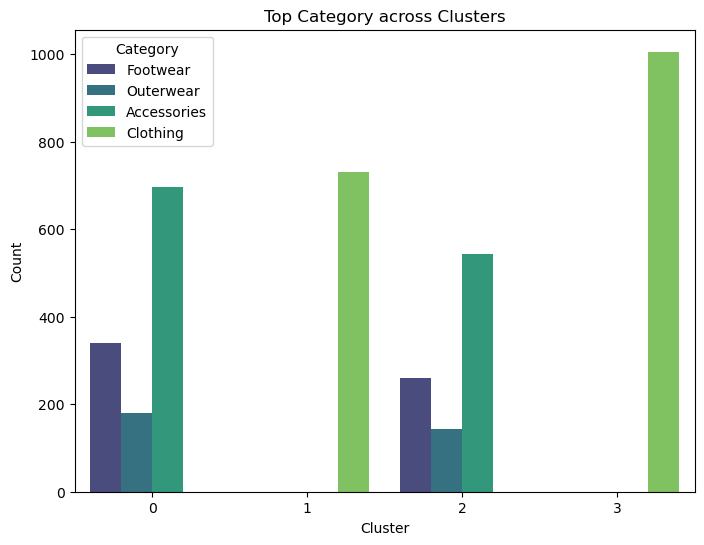

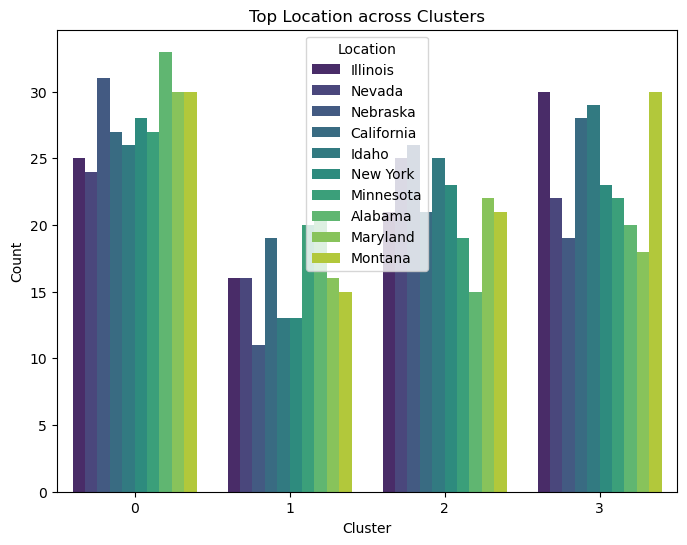

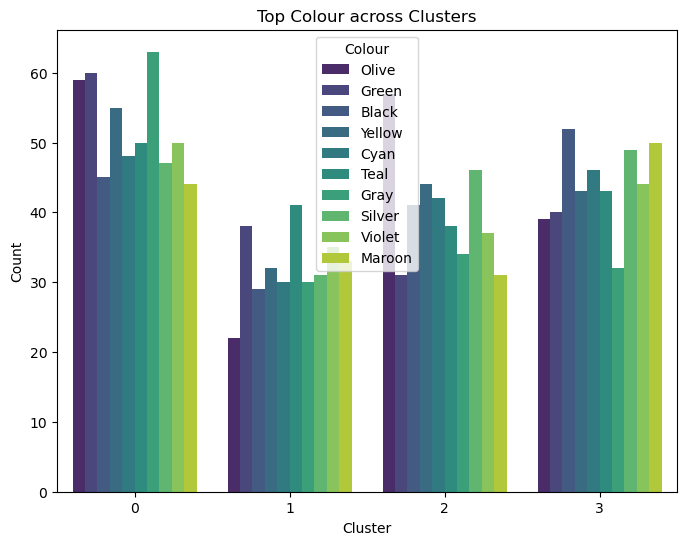

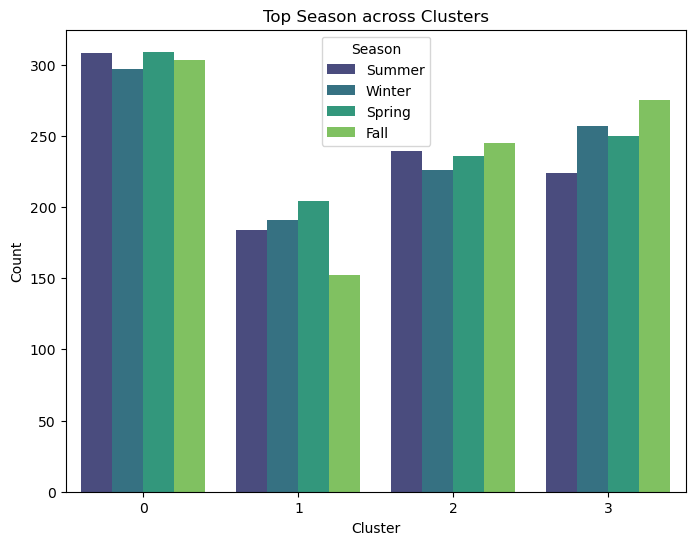

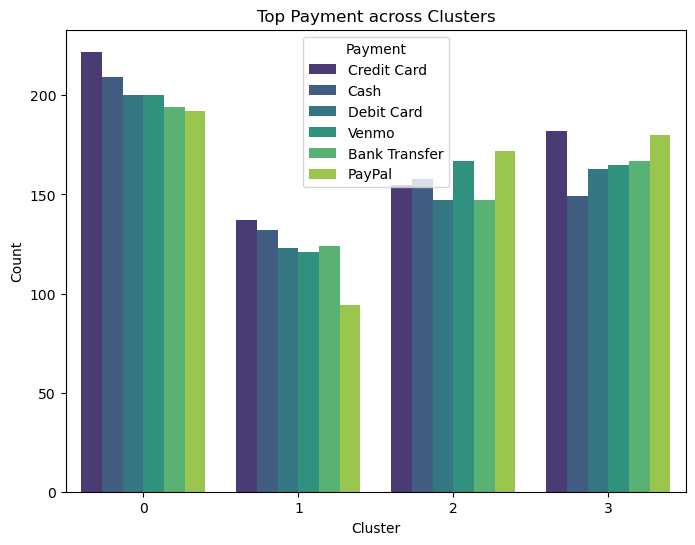

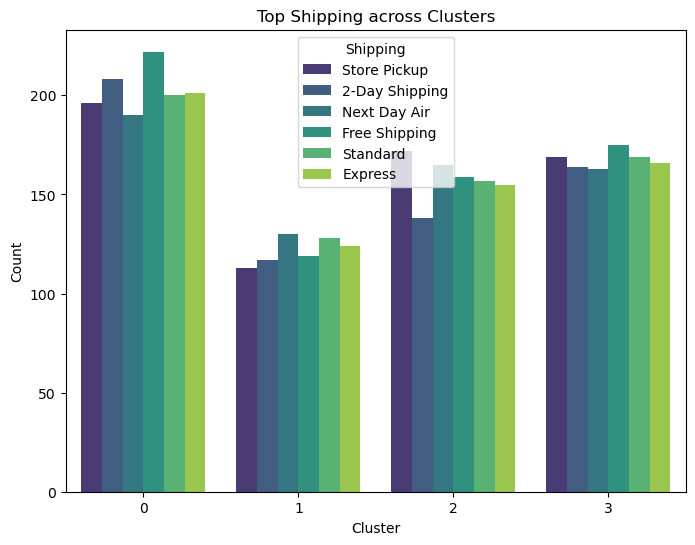

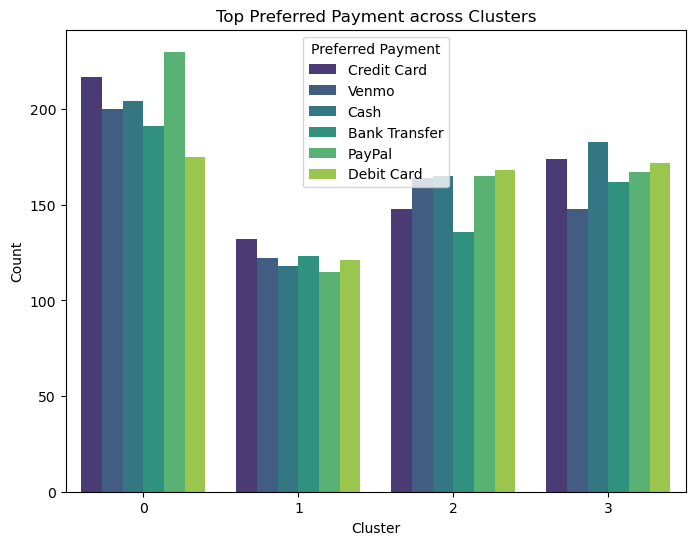

In [132]:
def onehot_graph(columns):
    for col in columns:
        plt.figure(figsize=(8, 6))
                            
        tops = alt[col].value_counts().nlargest(10).index
        filtered_data = alt[alt[col].isin(tops)]
        
        sns.countplot(data=filtered_data, x='Cluster', hue=col, palette='viridis')
        plt.title(f'Top {col} across Clusters')
        plt.xlabel('Cluster')
        plt.ylabel('Count')
        plt.legend(title=col)

        plt.show()

onehot_graph(ohe_col)


# <span style="color:blue"> Conclusions</span>

## <span style="color:red"> Segment Analysis</span>

Looking at the gender data, we can see that clusters 1 and 2 are only men, whereas 0 and 3 are a mix. This will be interesting

1. Next, we can see that clusters 1 and 2(only men) are the only ones subscribed. This indicates that this is a men-targeted store. My guess is that this store is similar to the clothing brand, Executive.

2. Again, the discount users are clusters 1 and 2. This brings so much more perspective! This indicates that discounts are available only to subscribers.

3. Remember in the beginning we mentioned that this store has either good marketing or absolutely good products in a way that people buy them even without discounts? Now we can conclude that it is more likely a marketing factor as the subscription rate is so much lower! This indicates that so many people are interested in buying the product, but only a very small portion are loyal and subscribed customers who go there again and again.

4. The ordinal graphs don't give much, if any, information, they all have similar shapes and distributions, pointing that these factors are just normally distributed in the sample or even in the public.

5. In one-hots we get to see very interesting groupings. We now have four distinct groups in this manner

0: Mix; Footwear, Outers, Accesories  
1: Men; Footwear, Outers, Accesories  
2: Men; Mainly Clothing  
3: Mix; Mainly Clothing  

Additionaly, we can also see that the store does well across all seasons, sharing similar increases and decreases per segment

## <span style="color:red"> Reflections, Advice, and Future Works</span>

One other interesting aspect that I found is that 0 makes up most of the sample, followed by 3, 1, and 2.  
If this data were truly random, then we now know that segment 0 probably brings the most revenue.

For future development in this business, pay attention to segments 1 and 2!! These people are very loyal but make up the smallest populations.

This means that the current problem is customer retention. A great job is being done by marketing as new customers are attracted again and again as show by segments 0 and 3

However, none of them want to stay! It's either the products are too niche, or there just isn't a WOW factor.

After concluding all this, I suggest that this store should do one of two things
1. IF the target market is indeed men such in segments 1 and 2, the store should focus on quality and uniqueness, retaining that niche target market and maybe even becoming the most trusted seller for that niche product.
2. IF the aforesaid target market is unintended, the store should focus on making better quality products. This will increase subscription rate and interest rate among the general public.